# CANSAT Duck2Dragon — Data Analysis

Reads `log.txt` from ground station serial logger (`read_serial.py`).

## CSV fields (23)
| # | Field | Unit | Source |
|---|-------|------|--------|
| 0 | millis | ms | ESP32 |
| 1 | lat | deg | GPS |
| 2 | lon | deg | GPS |
| 3 | alt_gps | m | GPS |
| 4 | sats | count | GPS |
| 5 | alt_baro | m | MS5611 |
| 6 | temp | °C | MS5611 |
| 7 | pressure | hPa | MS5611 |
| 8 | ax | m/s² | BNO085 linear accel |
| 9 | ay | m/s² | BNO085 linear accel |
| 10 | az | m/s² | BNO085 linear accel |
| 11 | gx | rad/s | BNO085 gyro |
| 12 | gy | rad/s | BNO085 gyro |
| 13 | gz | rad/s | BNO085 gyro |
| 14 | qw | — | BNO085 quaternion |
| 15 | qx | — | BNO085 quaternion |
| 16 | qy | — | BNO085 quaternion |
| 17 | qz | — | BNO085 quaternion |
| 18 | high_ax | g | ADXL375 |
| 19 | high_ay | g | ADXL375 |
| 20 | high_az | g | ADXL375 |
| 21 | voltage | V | INA219 |
| 22 | current | mA | INA219 |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOG_PATH = Path('log_1.txt')

COLUMNS = [
    'millis','lat','lon','alt_gps','sats',
    'alt_baro','temp','pressure',
    'ax','ay','az',
    'gx','gy','gz',
    'qw','qx','qy','qz',
    'high_ax','high_ay','high_az',
    'voltage','current'
]

rows = []
with open(LOG_PATH) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split(',')
        # Accept 23 or 24 fields (24 = trailing comma)
        if len(parts) >= 23:
            rows.append(parts[:23])  # Take first 23 fields

df = pd.DataFrame(rows, columns=COLUMNS)
df = df.apply(pd.to_numeric, errors='coerce')
df['time_s'] = df['millis'] / 1000.0

print(f'Loaded {len(df)} rows')
df.head()

Loaded 991 rows


,millis,lat,lon,alt_gps,sats,alt_baro,temp,pressure,ax,ay,...,qw,qx,qy,qz,high_ax,high_ay,high_az,voltage,current,time_s
0,128518.0,0.0,0.0,0.0,0,56.02,24.98,1006.54,0.0000,0.0000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.684,NaN,128.518
1,129351.0,0.0,0.0,0.0,0,55.85,24.98,1006.56,0.0312,0.1484,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.704,NaN,129.351
2,130201.0,0.0,0.0,0.0,0,56.18,24.99,1006.52,0.0000,0.0000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.696,NaN,130.201
3,131033.0,0.0,0.0,0.0,0,55.85,24.99,1006.56,-1.0000,-0.1758,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.708,NaN,131.033
4,131885.0,0.0,0.0,0.0,0,55.68,25.00,1006.58,0.0000,0.0000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.708,NaN,131.885


In [14]:
# Summary statistics
df.describe().round(3)

,millis,lat,lon,alt_gps,sats,alt_baro,temp,pressure,ax,ay,...,qw,qx,qy,qz,high_ax,high_ay,high_az,voltage,current,time_s
count,989.000,989.0,988.0,991.0,991.0,989.000,990.000,987.000,990.000,988.000,...,988.000,990.000,989.000,989.000,991.0,990.0,991.0,989.000,0.0,989.000
mean,679459.838,0.0,0.0,0.0,0.0,55.532,29.268,1006.600,-0.012,0.052,...,1.000,0.000,-0.000,0.007,0.0,0.0,0.0,3.700,NaN,679.460
std,338110.943,0.0,0.0,0.0,0.0,2.541,1.678,0.303,0.999,1.095,...,0.008,0.005,0.005,0.192,0.0,0.0,0.0,0.017,NaN,338.111
min,128518.000,0.0,0.0,0.0,0.0,33.110,24.940,1004.240,-5.570,-5.047,...,0.763,-0.060,-0.111,-0.248,0.0,0.0,0.0,3.480,NaN,128.518
25%,387206.000,0.0,0.0,0.0,0.0,54.010,29.193,1006.500,0.000,0.000,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.692,NaN,387.206
50%,665680.000,0.0,0.0,0.0,0.0,55.180,30.000,1006.640,0.000,0.000,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.704,NaN,665.680
75%,1000813.000,0.0,0.0,0.0,0.0,56.350,30.250,1006.780,0.086,0.115,...,1.000,0.000,0.000,0.000,0.0,0.0,0.0,3.712,NaN,1000.813
max,1269935.000,0.0,0.0,0.0,0.0,75.290,30.840,1009.280,4.918,5.582,...,1.000,0.142,0.032,6.000,0.0,0.0,0.0,3.728,NaN,1269.935


In [15]:
# Data quality check
print('NaN count per column:')
print(df.isna().sum())
print(f'\nGPS fix rows (sats > 0): {(df.sats > 0).sum()} / {len(df)}')
print(f'Baro valid rows (alt_baro != 0): {(df.alt_baro != 0).sum()} / {len(df)}')
print(f'Duration: {df.time_s.max():.1f} s')
print(f'Sample rate: {len(df)/df.time_s.max():.2f} Hz')

NaN count per column:
millis        2
lat           2
lon           3
alt_gps       0
sats          0
alt_baro      2
temp          1
pressure      4
ax            1
ay            3
az            0
gx            1
gy            4
gz            4
qw            3
qx            1
qy            2
qz            2
high_ax       0
high_ay       1
high_az       0
voltage       2
current     991
time_s        2
dtype: int64

GPS fix rows (sats > 0): 0 / 991
Baro valid rows (alt_baro != 0): 991 / 991
Duration: 1269.9 s
Sample rate: 0.78 Hz


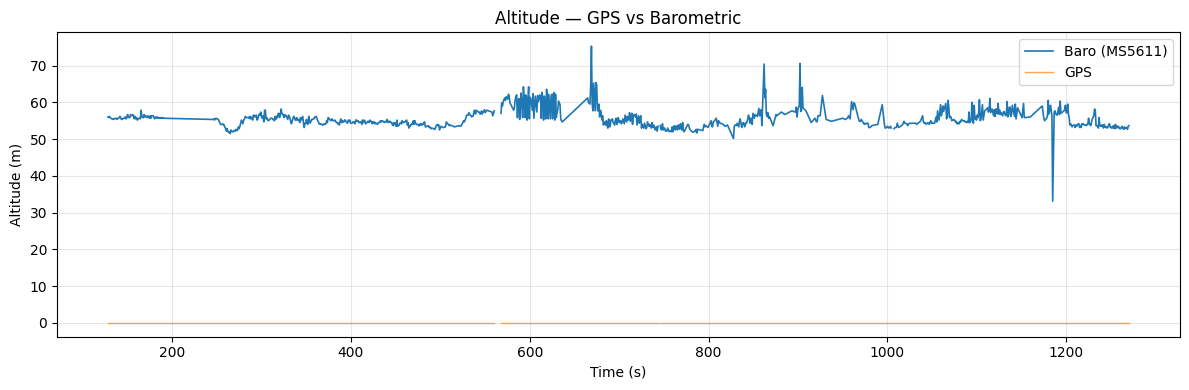

In [16]:
# Altitude: GPS vs Barometric
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.alt_baro, label='Baro (MS5611)', linewidth=1.2)
ax.plot(df.time_s, df.alt_gps,  label='GPS', linewidth=1.0, alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Altitude (m)')
ax.set_title('Altitude — GPS vs Barometric')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

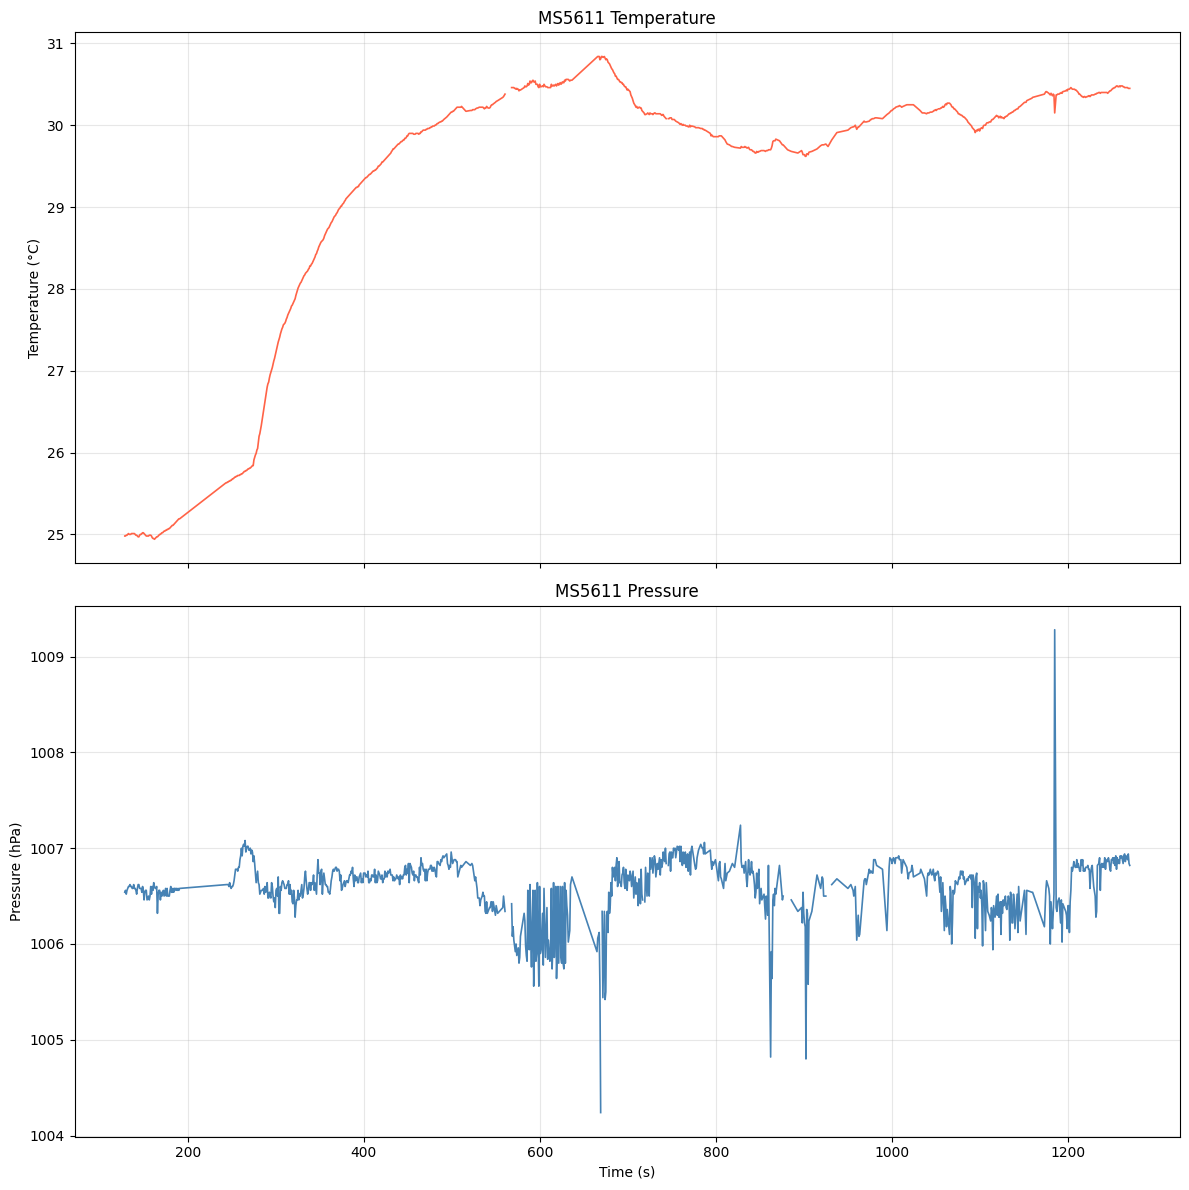

In [5]:
# Temperature & Pressure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
ax1.plot(df.time_s, df.temp, color='tomato', linewidth=1.2)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('MS5611 Temperature')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.pressure, color='steelblue', linewidth=1.2)
ax2.set_ylabel('Pressure (hPa)')
ax2.set_xlabel('Time (s)')
ax2.set_title('MS5611 Pressure')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

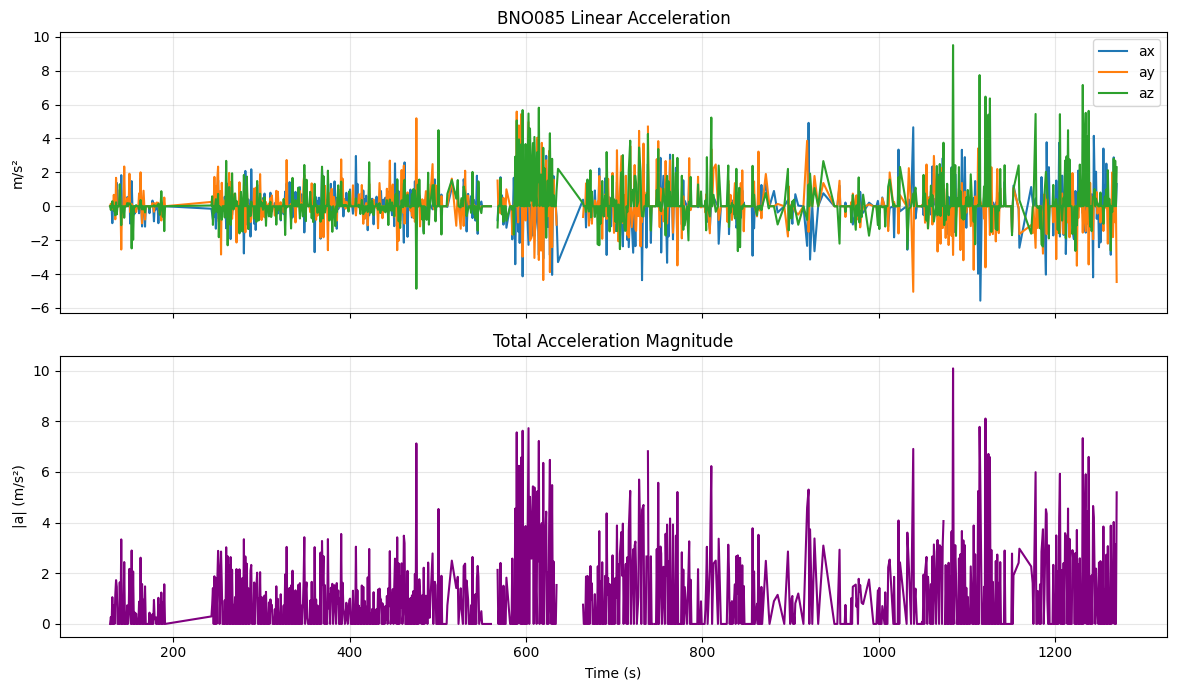

In [6]:
# BNO085 Linear Acceleration
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(df.time_s, df.ax, label='ax')
axes[0].plot(df.time_s, df.ay, label='ay')
axes[0].plot(df.time_s, df.az, label='az')
axes[0].set_ylabel('m/s²')
axes[0].set_title('BNO085 Linear Acceleration')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

df['accel_mag'] = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
axes[1].plot(df.time_s, df.accel_mag, color='purple')
axes[1].set_ylabel('|a| (m/s²)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Total Acceleration Magnitude')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

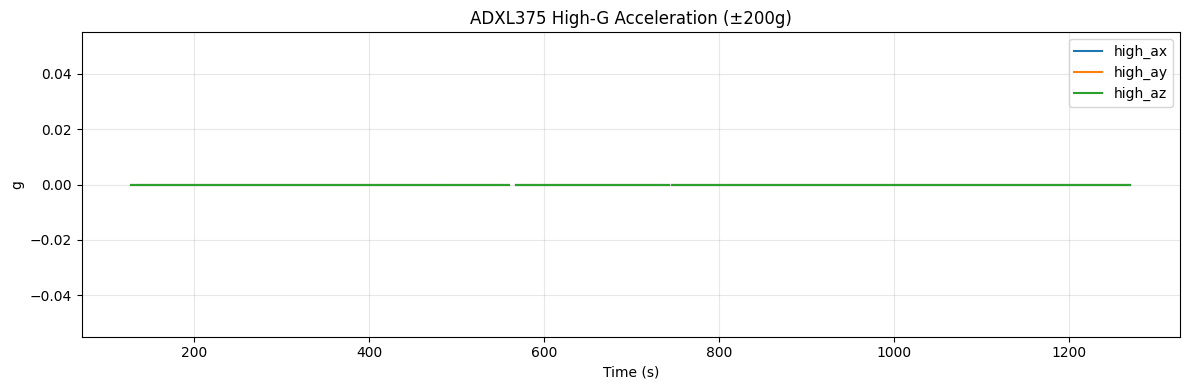

In [7]:
# ADXL375 High-G
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.high_ax, label='high_ax')
ax.plot(df.time_s, df.high_ay, label='high_ay')
ax.plot(df.time_s, df.high_az, label='high_az')
ax.set_xlabel('Time (s)')
ax.set_ylabel('g')
ax.set_title('ADXL375 High-G Acceleration (±200g)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

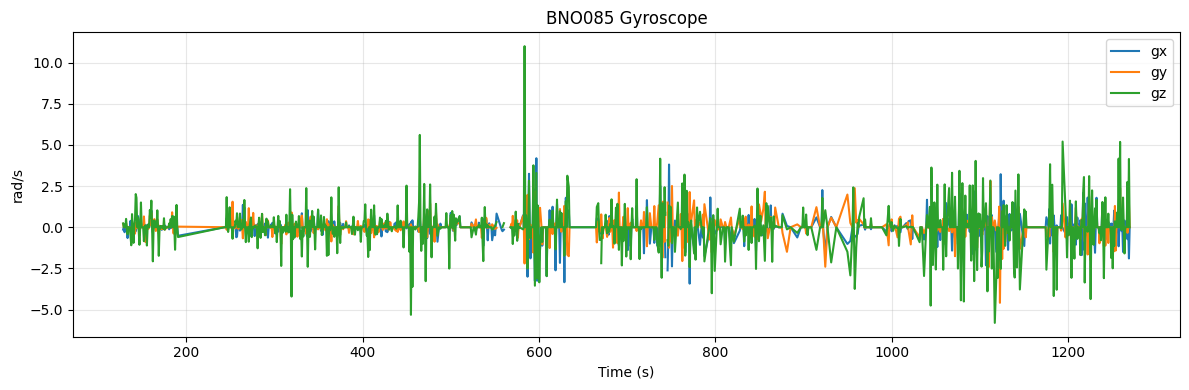

In [8]:
# BNO085 Gyroscope
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.gx, label='gx')
ax.plot(df.time_s, df.gy, label='gy')
ax.plot(df.time_s, df.gz, label='gz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('rad/s')
ax.set_title('BNO085 Gyroscope')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

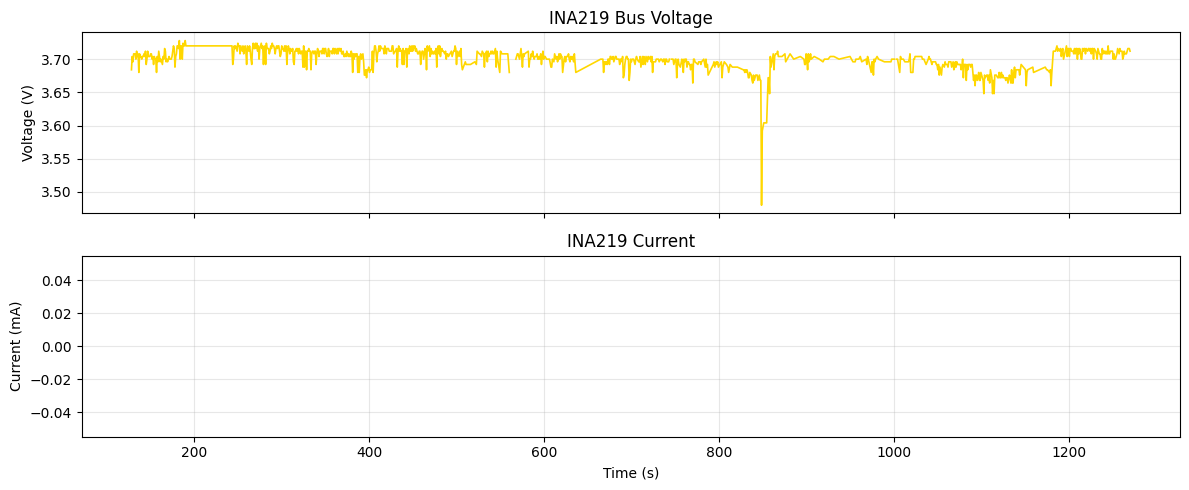

Avg voltage: 3.700 V
Avg current: nan mA
Avg power:   nan mW


In [9]:
# Power: Voltage & Current
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(df.time_s, df.voltage, color='gold', linewidth=1.2)
ax1.set_ylabel('Voltage (V)')
ax1.set_title('INA219 Bus Voltage')
ax1.grid(True, alpha=0.3)
ax2.plot(df.time_s, df.current, color='orange', linewidth=1.2)
ax2.set_ylabel('Current (mA)')
ax2.set_xlabel('Time (s)')
ax2.set_title('INA219 Current')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Avg voltage: {df.voltage.mean():.3f} V')
print(f'Avg current: {df.current.mean():.1f} mA')
print(f'Avg power:   {(df.voltage * df.current).mean():.1f} mW')

In [10]:
# GPS Track — Interactive Map (Mapbox)
import plotly.express as px

gps_valid = df[(df.sats > 0) & (df.lat != 0) & (df.lon != 0)]
if len(gps_valid) > 0:
    fig = px.scatter_mapbox(
        gps_valid,
        lat='lat',
        lon='lon',
        color='alt_gps',    
        size_max=10,
        zoom=14,
        height=600,
        color_continuous_scale='Viridis',
        labels={'alt_gps': 'Altitude (m)'},
        title=f'GPS Track ({len(gps_valid)} points)',
        mapbox_style="open-street-map"
    )
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.show()
else:
    print('No valid GPS fix in log.')

No valid GPS fix in log.


Apogee (baro): 75.29 m at t=669.0 s


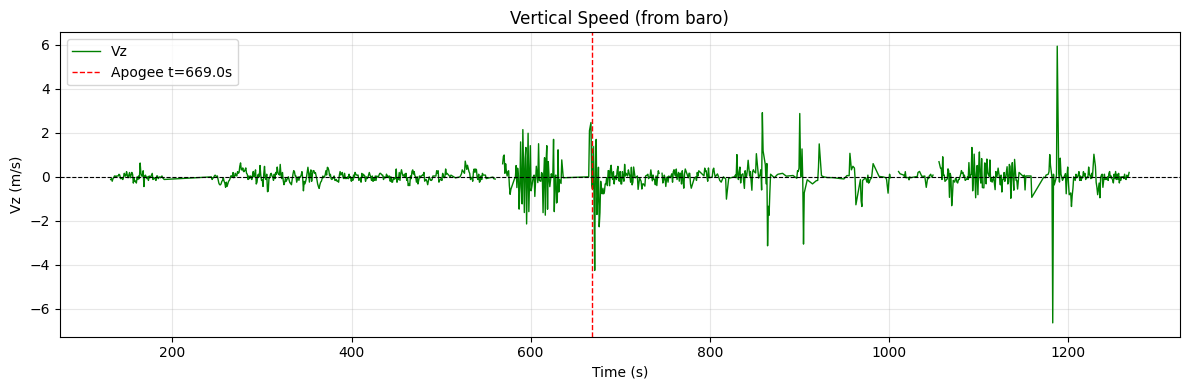

In [11]:
# Apogee detection + vertical speed
idx_apogee = df.alt_baro.idxmax()
apogee_alt = df.alt_baro[idx_apogee]
apogee_t   = df.time_s[idx_apogee]
print(f'Apogee (baro): {apogee_alt:.2f} m at t={apogee_t:.1f} s')

df['alt_smooth'] = df.alt_baro.rolling(5, center=True).mean()
df['vz'] = df.alt_smooth.diff() / df.time_s.diff()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.time_s, df.vz, color='green', linewidth=1.0, label='Vz')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(apogee_t, color='red', linewidth=1.0, linestyle='--', label=f'Apogee t={apogee_t:.1f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Vz (m/s)')
ax.set_title('Vertical Speed (from baro)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Export cleaned CSV
out_path = Path('log_clean.csv')
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} rows to {out_path}')

Saved 991 rows to log_clean.csv
